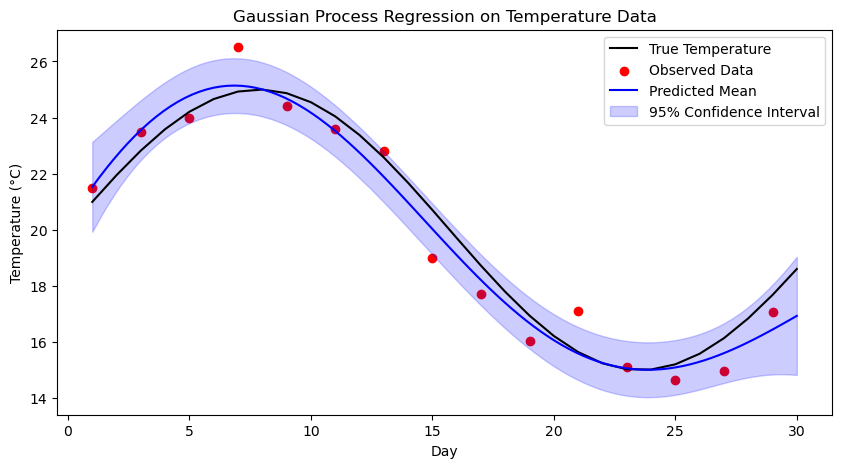

Optimized kernel: 17**2 * RBF(length_scale=14)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Generate synthetic temperature data
np.random.seed(42)
days = np.linspace(1, 30, 30).reshape(-1, 1)  # 30 days
true_temp = 20 + 5 * np.sin(0.2 * days)  # Sinusoidal temperature pattern
noise = np.random.normal(0, 1, days.shape)  # Add noise
observed_temp = true_temp + noise

# Define training and test data
X_train = days[::2]  # Every other day for training
y_train = observed_temp[::2].ravel()
X_test = np.linspace(1, 30, 100).reshape(-1, 1)  # Finer grid for prediction

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Set up the Gaussian Process Regressor
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=10.0, length_scale_bounds=(1e-2, 1e2))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1.0)

# Fit the model
gpr.fit(X_train, y_train)

# Make predictions
y_pred, sigma = gpr.predict(X_test, return_std=True)

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(days, true_temp, 'k-', label='True Temperature')
plt.scatter(X_train, y_train, c='red', label='Observed Data')
plt.plot(X_test, y_pred, 'b-', label='Predicted Mean')
plt.fill_between(X_test.ravel(), y_pred - 1.96 * sigma, y_pred + 1.96 * sigma,
                 alpha=0.2, color='blue', label='95% Confidence Interval')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.title('Gaussian Process Regression on Temperature Data')
plt.legend()
plt.show()

# Print optimized kernel parameters
print(f"Optimized kernel: {gpr.kernel_}")